In [ ]:
# !pip install -U torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
import torch
print(torch.cuda.device_count())  


1


In [ ]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# # Install Pytorch & other libraries
# %pip install "torch>=2.4.0" tensorboard torchvision

# # Install Gemma release branch from Hugging Face
# %pip install "transformers>=4.51.3"

# # Install Hugging Face libraries
# %pip install  --upgrade \
#   "datasets==3.3.2" \
#   "accelerate==1.4.0" \
#   "evaluate==0.4.3" \
#   "bitsandbytes==0.45.3" \
#   "trl==0.15.2" \
#   "peft==0.14.0" \
#   "pillow==11.1.0" \
#   protobuf \
#   sentencepiece

In [ ]:
# import os

# # List input directory contents
# os.listdir("/kaggle/input")


['optimal-carving-475915-u7-4c85df30bf2f', 'balanced-longitudinal-balanced']

In [ ]:
import os
from google.cloud import storage
import cv2
import numpy as np

#  Set your credentials
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] ="/content/optimal-carving-475915-u7-4c85df30bf2f.json"

#  Initialize the client with your project
project_id = "bernices-ai-project"
client = storage.Client(project=project_id)

In [ ]:
# Initializing the GCS client
client = storage.Client()

# Defining the bucket name
bucket_name = "bernices-xray-dataset"

# Get the bucket
bucket = client.bucket(bucket_name)


In [ ]:
import numpy as np
import cv2

blob = bucket.blob("PNG/train/patient00007/study1/view1_frontal.png")
image_bytes = blob.download_as_bytes()
image = cv2.imdecode(np.frombuffer(image_bytes, np.uint8), cv2.IMREAD_COLOR)

print(" Image loaded successfully from private GCS bucket")
print("Image shape:", image.shape)

 Image loaded successfully from private GCS bucket
Image shape: (2320, 2828, 3)


In [ ]:
csv_path= "/content/balanced_longitudinal_balanced.csv"

In [ ]:
import sys
print('tensorflow' in sys.modules)  


False


In [ ]:
# pip install trl

In [ ]:
import pandas as pd
import gcsfs
from PIL import Image
from io import BytesIO
from IPython.display import display
from peft import LoraConfig, get_peft_model
from transformers import  AutoProcessor, BitsAndBytesConfig
import torch
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
import gc
from huggingface_hub import login
import gcsfs
from transformers import AutoModelForVision2Seq, AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training, get_peft_model, LoraConfig
from google.cloud import storage
import cv2
import numpy as np

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
df= pd.read_csv(csv_path)

In [ ]:
df.columns

Index(['patient_id', 'prior_image_path', 'prior_report', 'prior_study_order',
       'prior_age', 'prior_frontal_lateral', 'prior_ap_pa',
       'prior_section_findings', 'prior_section_impression',
       'prior_recent_bmi', 'current_image_path', 'current_report',
       'current_study_order', 'current_age', 'current_frontal_lateral',
       'current_ap_pa', 'current_section_findings',
       'current_section_impression', 'current_recent_bmi', 'sex'],
      dtype='object')

In [ ]:
df["current_image_path"][0]

'/content/drive/MyDrive/capstone/extracted_data/PNG/train/patient00007/study2/view1_frontal.png'

In [ ]:
df.isna().sum()

,0
patient_id,0
prior_image_path,0
prior_report,0
prior_study_order,0
prior_age,5
prior_frontal_lateral,0
prior_ap_pa,560
prior_section_findings,1928
prior_section_impression,0
prior_recent_bmi,820


In [ ]:
cols = [
    "current_age",
    "current_report",
    "sex",
    "current_frontal_lateral",
    "prior_report",
    "current_image_path",
    "current_recent_bmi"
]

# Saving only the selected columns
df[cols].to_csv("selected_data.csv", index=False)

print(" Saved 'selected_data.csv' with selected columns only!")

 Saved 'selected_data.csv' with selected columns only!


In [ ]:
data= pd.read_csv("selected_data.csv")


In [ ]:
data.head(5)

,current_age,current_report,sex,current_frontal_lateral,prior_report,current_image_path,current_recent_bmi
0,69.0,"HISTORY: Male, 69 years old, intubated. COMPAR...",Male,Frontal,"HISTORY: Male, 69 years old, Check tube placem...",/content/drive/MyDrive/capstone/extracted_data...,NaN
1,81.0,"HISTORY: 81 years of age, Male, Increased O2 r...",Male,Frontal,"HISTORY: 81 years of age, Male, Recent respira...",/content/drive/MyDrive/capstone/extracted_data...,25.9
2,64.0,HISTORY: Critical care follow up. COMPARISON: ...,Male,Frontal,COMPARISON: None. CLINICAL HISTORY: A 63-year-...,/content/drive/MyDrive/capstone/extracted_data...,NaN
3,81.0,COMPARISON: 5/13/2004 and 5-13-FINDINGS: Since...,Male,Lateral,COMPARISON: 8-3-2005 and 8-3-FINDINGS: Since t...,/content/drive/MyDrive/capstone/extracted_data...,20.1
4,29.0,"HISTORY: Male, 29 years old, with chest pain. ...",Male,Frontal,"HISTORY: Male, 29 years old, with chest pain. ...",/content/drive/MyDrive/capstone/extracted_data...,28.3


In [ ]:
data.isna().sum()

,0
current_age,5
current_report,0
sex,0
current_frontal_lateral,0
prior_report,0
current_image_path,0
current_recent_bmi,820


In [ ]:
data['current_age'] = data['current_age'].fillna(data['current_age'].median())
data['current_recent_bmi'] = data['current_recent_bmi'].fillna(data['current_recent_bmi'].mean())

In [ ]:
data.isna().sum()

,0
current_age,0
current_report,0
sex,0
current_frontal_lateral,0
prior_report,0
current_image_path,0
current_recent_bmi,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2893 entries, 0 to 2892
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   current_age              2893 non-null   float64
 1   current_report           2893 non-null   object 
 2   sex                      2893 non-null   object 
 3   current_frontal_lateral  2893 non-null   object 
 4   prior_report             2893 non-null   object 
 5   current_image_path       2893 non-null   object 
 6   current_recent_bmi       2893 non-null   float64
dtypes: float64(2), object(5)
memory usage: 158.3+ KB


In [ ]:
data["current_report"][0]

'HISTORY: Male, 69 years old, intubated. COMPARISON: 7/20/IMPRESSION: Low lung volumes. Stable moderate enlargement of the cardiomediastinal silhouette. Normal pulmonary vascularity. Patchy opacity at the left lung base, likely atelectasis. No pleural effusion or pneumothorax. No fractures identified. Endotracheal tube tip is in the mid trachea, overlying the T4 vertebral body.'

In [ ]:
data["prior_report"][0]

'HISTORY: Male, 69 years old, Check tube placement. COMPARISON: None. IMPRESSION: Low lung volumes, and overlying trauma board limit evaluation. There is prominence of the cardiac shadow, likely reflecting cardiomegaly, and retrocardiac opacity, likely representing atelectasis. No definite pleural fluid. The left costophrenic sulcus is not included, limiting evaluation for pneumothorax. Endotracheal tube tip is in the mid trachea, overlying the T4 vertebral body. No fracture identified.'

In [ ]:
data['current_image_path'] = data['current_image_path'].str.replace(
    '/content/drive/MyDrive/capstone/extracted_data/PNG',
    'gs://bernices-xray-dataset/PNG',
    regex=False
)

print(" Image paths updated to point to GCS!")
print(data['current_image_path'].head())


 Image paths updated to point to GCS!
0    gs://bernices-xray-dataset/PNG/train/patient00...
1    gs://bernices-xray-dataset/PNG/train/patient00...
2    gs://bernices-xray-dataset/PNG/train/patient00...
3    gs://bernices-xray-dataset/PNG/train/patient00...
4    gs://bernices-xray-dataset/PNG/train/patient00...
Name: current_image_path, dtype: object


In [ ]:
data.sample(3)[['current_image_path']]

,current_image_path
1599,gs://bernices-xray-dataset/PNG/train/patient45...
2783,gs://bernices-xray-dataset/PNG/train/patient05...
298,gs://bernices-xray-dataset/PNG/train/patient08...


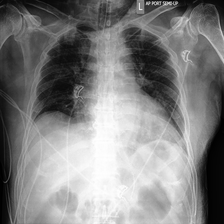

Image loaded and resized to: (224, 224)


In [ ]:
"""
Loading an image from the Google Cloud Storage to ensure
that everything is successfully authenticated.


"""


# Path to your uploaded key
json_key_path = "/content/optimal-carving-475915-u7-4c85df30bf2f.json"



# Authenticating with google cloud storage
fs = gcsfs.GCSFileSystem(token=json_key_path)

# Image path
img_path = "gs://bernices-xray-dataset/PNG/train/patient00007/study2/view1_frontal.png"

with fs.open(img_path, 'rb') as f:
    img = Image.open(BytesIO(f.read())).convert("RGB")

new_size = (224, 224)  
resized_img = img.resize(new_size, Image.LANCZOS)

# Displaying the  resized image
display(resized_img)
print(f"Image loaded and resized to: {new_size}")


In [ ]:
# # Split into train and eval sets
# train_df = data.sample(frac=0.9, random_state=42)
# eval_df = data.drop(train_df.index)

# print(f"Train: {len(train_df)} | Eval: {len(eval_df)}")

In [ ]:
data.columns

Index(['current_age', 'current_report', 'sex', 'current_frontal_lateral',
       'prior_report', 'current_image_path', 'current_recent_bmi'],
      dtype='object')

# MODEL TRAINING

The model is loaded using the LoRA config and quantisation. Why Lora config and quantisation?
This section loads the model in an efficient, memory-saving way using 4-bit quantization and prepares it for LoRA fine-tuning. Quantization reduces the model’s weights from full precision down to compact 4-bit representations using the BitsAndBytes configuration, which significantly lowers GPU memory usage while keeping the model accurate by applying advanced techniques like NF4 quantization, double-quantization, and bfloat16 computation. After loading the quantized model, the LoRA configuration will later inject small trainable adapter layers into key transformer components while keeping the main model frozen. Together, quantization and LoRA allow the model to be fine-tuned cheaply and efficiently, enabling large vision-language models like SmolVLM-500M to train on limited hardware while still achieving strong performance improvements.

In [ ]:
#Model loading using quantization and Loraconfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype="bfloat16"
)

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
#model.cuda:0
model.to(device)

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Using device: cuda


Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (v_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (q_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (out_proj): Linear4bit(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear4bit(

In [ ]:

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "v_proj", "k_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 9,568,256 || all params: 517,050,560 || trainable%: 1.8505


Lora config prepares the model for efficient LoRA fine-tuning by enabling low-precision (k-bit) training and adding small trainable adapter layers to key transformer components while keeping the main model frozen. The LoraConfig specifies how these adapters should be inserted—using small low-rank matrices (r=16), a scaling factor (alpha=32), slight dropout to prevent overfitting, and targeting important modules like the attention projections (q_proj, k_proj, v_proj, o_proj) and feed-forward layers. When get_peft_model is applied, the model is wrapped with these LoRA adapters so only a tiny fraction of parameters are updated during training. print_trainable_parameters() confirms that most of the original model remains frozen, allowing fine-tuning to be fast, memory-efficient, and effective even on limited hardware.

In [ ]:
import torch
print(torch.cuda.device_count())

for name, param in model.named_parameters():
    if "lora" in name:
        print(name, param.device)
        break


1
base_model.model.model.vision_model.encoder.layers.0.self_attn.k_proj.lora_A.default.weight cuda:0


In [ ]:
train_df = data.sample(frac=0.9, random_state=42)
eval_df = data.drop(train_df.index)

In [ ]:
train_df

,current_age,current_report,sex,current_frontal_lateral,prior_report,current_image_path,current_recent_bmi
1905,82.0,COMPARISON: July 13th IMPRESSION: INITIAL 7-13...,Female,Frontal,COMPARISON: 10-20-IMPRESSION: INITIAL 10/20/20...,gs://bernices-xray-dataset/PNG/train/patient54...,26.20193
1055,63.0,COMPARISON: 7/18/CLINICAL HISTORY: Acetabular ...,Male,Frontal,IMPRESSION: LIMITED TRAUMA BOARD CHEST RADIOGR...,gs://bernices-xray-dataset/PNG/train/patient30...,28.60000
2471,65.0,COMPARISON: 6-25-2010 IMPRESSION: REDEMONSTRAT...,Female,Lateral,COMPARISON: 6-25-2010 IMPRESSION: REDEMONSTRAT...,gs://bernices-xray-dataset/PNG/train/patient25...,26.80000
1133,36.0,"HISTORY: 35 years Male, Back pain. COMPARISON:...",Male,Lateral,"HISTORY: 35 years Male, Back pain. COMPARISON:...",gs://bernices-xray-dataset/PNG/train/patient33...,26.20193
1200,89.0,COMPARISON: COMPARISON is made with prior stud...,Male,Frontal,COMPARISON: 1/10/2017 IMPRESSION: INTERVAL EXT...,gs://bernices-xray-dataset/PNG/train/patient35...,26.20193
...,...,...,...,...,...,...,...
2870,32.0,"HISTORY: 32 years of age, Female, Critical Car...",Female,Frontal,"HISTORY: 32 years of age, Female, Critical Car...",gs://bernices-xray-dataset/PNG/train/patient39...,19.40000
639,51.0,COMPARISON: 11/12/2005 IMPRESSION: INTERVAL RE...,Male,Frontal,COMPARISON: None. IMPRESSION: SINGLE PORTABLE ...,gs://bernices-xray-dataset/PNG/train/patient18...,30.20000
2681,70.0,"COMPARISON: None. CLINICAL HISTORY: Syncope, r...",Male,Frontal,"COMPARISON: None. CLINICAL HISTORY: Syncope, r...",gs://bernices-xray-dataset/PNG/train/patient13...,28.60000
1218,64.0,COMPARISON: Chest x-ray 08/17/2017 CLINICAL HI...,Male,Frontal,HISTORY: This is a 64-year-old male with epiga...,gs://bernices-xray-dataset/PNG/train/patient36...,30.70000


In [ ]:
train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(eval_df)

In [ ]:
train_dataset

Dataset({
    features: ['current_age', 'current_report', 'sex', 'current_frontal_lateral', 'prior_report', 'current_image_path', 'current_recent_bmi', '__index_level_0__'],
    num_rows: 2604
})

In [ ]:
eval_dataset

Dataset({
    features: ['current_age', 'current_report', 'sex', 'current_frontal_lateral', 'prior_report', 'current_image_path', 'current_recent_bmi', '__index_level_0__'],
    num_rows: 289
})

# Preparing the Data in a format that can be used by the model

This function prepares each row of your longitudinal dataset into the correct chat-style training format required for SmolVLM fine-tuning. For every study, it extracts the patient's metadata, prior report, current report, and image path, then builds a structured prompt that teaches the model how to generate a new radiology report using only the image and metadata—without copying from the prior report. The format_for_sft() function creates a three-message chat sequence: a system message defining the radiologist persona, a user message containing the metadata, prior report, and the X-ray image, and an assistant message containing the correct current report (ground truth). It also checks whether the image exists in Google Cloud Storage and skips rows with missing files to avoid errors. The generate_formatted_data() function streams these formatted samples one by one, which prevents memory overload for large datasets and triggers garbage collection periodically. Together, these functions efficiently convert your dataset into the precise structure required for supervised fine-tuning of a vision-language model.

In [ ]:
import gcsfs, gc
from datasets import Dataset

fs = gcsfs.GCSFileSystem(
    token="/content/optimal-carving-475915-u7-4c85df30bf2f.json"
)

system_message = "You are an expert radiologist specialized in interpreting chest X-rays."

def format_for_sft(row):
    """
    Format each row into SmolVLM chat training format.
    - PRIOR report → included in user prompt only (cannot leak into assistant output)
    - CURRENT report → assistant output (ground truth)
    """
    try:
        age  = row.get("current_age", "unknown")
        sex  = row.get("sex", "unknown")
        bmi  = row.get("current_recent_bmi", "unknown")
        view = row.get("current_frontal_lateral", "unknown")

        prior   = row.get("prior_report", "").strip()          #  PRIOR report
        current = row.get("current_report", "").strip()        #  Current  (ground truth)

        img_path = row.get("current_image_path")

        # this is to ensure that it Skips rows where image is missing or GCS file doesn't exist
        if not img_path or not fs.exists(img_path):
            return None

        # User prompt WITHOUT <image> text token
        user_prompt = f"""
Generate the CURRENT chest X-ray report based ONLY on the image and metadata.
Do NOT copy or repeat any part of the prior report.
Write a NEW independent FINDINGS and IMPRESSION.

Patient information:
Age: {age} years
Sex: {sex}
BMI: {bmi}
View type: {view}

Prior report (reference ONLY, do not copy):
{prior}

Provide structured FINDINGS and IMPRESSION.
""".strip()

        return {
            "messages": [
                {
                    "role": "system",
                    "content": [{"type": "text", "text": system_message}]
                },
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": user_prompt},
                        {"type": "image", "image": img_path}     
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": current}]   
                }
            ]
        }

    except Exception:
        return None



def generate_formatted_data(df):
    """
    Stream rows one-by-one to avoid high memory usage.
    Ensures GC runs every 200 rows.
    """
    for i, (_, row) in enumerate(df.iterrows()):
        formatted = format_for_sft(row)
        if formatted is not None:
            yield formatted

        # safe garbage collection every 200 rows
        if i % 200 == 0:
            gc.collect()


In [ ]:
train_df.columns

Index(['current_age', 'current_report', 'sex', 'current_frontal_lateral',
       'prior_report', 'current_image_path', 'current_recent_bmi'],
      dtype='object')

In [ ]:
# count = 0
# for item in generate_formatted_data(train_df):
#     count += 1
#     if count == 5:
#         break

# print("Generated:", count)


In [ ]:
# print("Building train dataset (streaming mode)...")
# train_ds = Dataset.from_generator(lambda: generate_formatted_data(train_df))

# print("Building eval dataset (streaming mode)...")
# eval_ds = Dataset.from_generator(lambda: generate_formatted_data(eval_df))

# train_path = "/kaggle/working/train_formatted"
# eval_path = "/kaggle/working/eval_formatted"

# train_ds.save_to_disk(train_path)
# eval_ds.save_to_disk(eval_path)

# print("Datasets saved successfully!")
# print(f"Train: {train_path}")
# print(f"Eval:  {eval_path}")

# del train_ds, eval_ds
# gc.collect()
# print("Memory cleaned up — safe to continue fine-tuning")

In [ ]:
# from datasets import load_from_disk

# train_ds = load_from_disk("/kaggle/working/train_formatted")
# eval_ds = load_from_disk("/kaggle/working/eval_formatted")

In [ ]:
from huggingface_hub import login
login("")

In [ ]:
# train_ds.push_to_hub(
#     "Awinpang/smolvlm-radiology-data",
#     split="train",
#     private=True,
#     commit_message="Updated dataset with correct prior/current report mapping"
# )

# eval_ds.push_to_hub(
#     "Awinpang/smolvlm-radiology-data",
#     split="validation",
#     private=True,
#     commit_message="Updated dataset with correct prior/current report mapping"
# )


In [ ]:
# import json
# print(json.dumps(train_ds[0], indent=2))


In [ ]:
# for item in train_ds[0]["messages"][1]["content"]:
#     print(item)


In [ ]:

# # Your repo ID
# repo_id = "Awinpang/smolvlm-radiology-data"

# # Push both splits
# train_ds.push_to_hub(
#     repo_id,
#     split="train",
#     private=True
# )

# eval_ds.push_to_hub(
#     repo_id,
#     split="validation",
#     private=True
# )

# print("Datasets pushed successfully!")


In [ ]:
#Loading the formatted dataset from kaggle
dataset = load_dataset("Awinpang/smolvlm-radiology-data")
train_ds = dataset["train"]
eval_ds  = dataset["validation"]

In [ ]:
train_ds

Dataset({
    features: ['messages'],
    num_rows: 2604
})

In [ ]:
print("Train size after map:", len(train_ds))
print("Eval size after map:", len(eval_ds))
print("Sample keys:", train_ds.column_names)

Train size after map: 2604
Eval size after map: 289
Sample keys: ['messages']


# COLLATE FUNCTION
The collate_fn_smolvlm function is responsible for converting each training example into the exact format required by SmolVLM: it extracts the system message, user text, image path, and assistant (ground-truth) report, safely loads the image, and uses the model’s processor to convert the chat messages into tokenized text and pixel embeddings. It also builds two versions of the conversation: the full sequence (system + user + assistant) and the prompt-only version (system + user). The difference between them is used to create the labels tensor: all tokens belonging to the prompt are masked with -100, so the model only learns to predict the assistant’s part of the text. Finally, the function pads all text sequences to the same length, pads image tensors across the batch, and returns a dictionary containing input_ids, attention_mask, pixel_values, and labels, all aligned and ready for training. This ensures robust batching, safe image loading, and correct supervision for your vision-language fine-tuning pipeline.

In [ ]:
import os, hashlib, torch
from torch.nn.utils.rnn import pad_sequence
from PIL import Image, ImageFile
from io import BytesIO

ImageFile.LOAD_TRUNCATED_IMAGES = True

#Image cache 
CACHE_DIR = "/kaggle/working/image_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def safe_load_image(path):
    try:
        return Image.open(path).convert("RGB")
    except:
        print("Corrupted cached image:", path)
        return Image.new("RGB", (224, 224))

def get_cached_image(img_ref):
    fname = hashlib.md5(img_ref.encode()).hexdigest() + ".png"
    local_path = os.path.join(CACHE_DIR, fname)

    if os.path.exists(local_path):
        return safe_load_image(local_path)

    try:
        with fs.open(img_ref, "rb") as f:
            data = f.read()
        img = Image.open(BytesIO(data)).convert("RGB")
        img.save(local_path)
        return img
    except Exception as e:
        print("Broken GCS image:", img_ref, e)
        return Image.new("RGB", (224, 224))

IMAGE_SEQ_LEN = 1


def collate_fn_smolvlm(batch):
    global processor

    input_ids_list = []
    attention_mask_list = []
    labels_list = []
    pixel_values_list = []

    for ex in batch:
        messages = ex.get("messages")
        if not messages:
            continue

        system_msg = next((m for m in messages if m["role"] == "system"), None)
        user_msg   = next((m for m in messages if m["role"] == "user"), None)
        asst_msg   = next((m for m in messages if m["role"] == "assistant"), None)
        if not (system_msg and user_msg and asst_msg):
            continue

        user_text, image_path = "", None
        for item in user_msg["content"]:
            if item["type"] == "text":
                user_text = item["text"]
            elif item["type"] == "image":
                image_path = item["image"]

        if not image_path:
            continue

        assistant_text = asst_msg["content"][0]["text"]

        # Load image safelyto ensure ,the images doesn't get corrupted while loading
        image = get_cached_image(image_path)

        # Building template chats
        full_messages = [
            {"role": "system",     "content": [{"type": "text", "text": system_msg["content"][0]["text"]}]},
            {"role": "user",       "content": [{"type": "image"}, {"type": "text", "text": user_text}]},
            {"role": "assistant",  "content": [{"type": "text", "text": assistant_text}]},
        ]

        prompt_messages = [
            {"role": "system", "content": [{"type": "text", "text": system_msg["content"][0]["text"]}]},
            {"role": "user",   "content": [{"type": "image"}, {"type": "text", "text": user_text}]},
        ]

        full_text = processor.apply_chat_template(full_messages, tokenize=False)
        prompt_text = processor.apply_chat_template(prompt_messages, tokenize=False)

        enc_full = processor(
            text=full_text,
            images=[image],
            image_seq_len=IMAGE_SEQ_LEN,
            return_tensors="pt",
        )

        enc_prompt = processor(
            text=prompt_text,
            images=[image],
            image_seq_len=IMAGE_SEQ_LEN,
            return_tensors="pt",
        )

        ids = enc_full["input_ids"].squeeze(0)
        attn = enc_full["attention_mask"].squeeze(0)
        pixel_vals = enc_full["pixel_values"]  

        prompt_len = enc_prompt["input_ids"].size(1)

        labels = ids.clone()
        labels[:prompt_len] = -100

        input_ids_list.append(ids)
        attention_mask_list.append(attn)
        labels_list.append(labels)
        pixel_values_list.append(pixel_vals)

    if not input_ids_list:
        raise RuntimeError("No valid samples produced. Check dataset formatting or image paths.")

    # padding the tokenizer
    pad_id = processor.tokenizer.pad_token_id

    input_ids = pad_sequence(input_ids_list, batch_first=True, padding_value=pad_id)
    attention_mask = pad_sequence(attention_mask_list, batch_first=True, padding_value=0)
    labels = pad_sequence(labels_list, batch_first=True, padding_value=-100)

    max_patches = max(pv.shape[1] for pv in pixel_values_list)

    padded_images = []
    for pv in pixel_values_list:
        patches = pv.shape[1]
        if patches < max_patches:
            pad = torch.zeros((pv.shape[0], max_patches - patches, pv.shape[2], pv.shape[3], pv.shape[4]))
            pv = torch.cat([pv, pad], dim=1)
        padded_images.append(pv)

    pixel_values = torch.cat(padded_images, dim=0)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "pixel_values": pixel_values,
        "labels": labels,
    }


In [ ]:
print(train_ds[0].keys())

dict_keys(['messages'])


In [ ]:
print(train_ds[0])

{'messages': [{'content': [{'image': None, 'text': 'You are an expert radiologist specialized in interpreting chest X-rays.', 'type': 'text'}], 'role': 'system'}, {'content': [{'image': None, 'text': 'Generate the CURRENT chest X-ray report based ONLY on the image and metadata.\nDo NOT copy or repeat any part of the prior report.\nWrite a NEW independent FINDINGS and IMPRESSION.\n\nPatient information:\nAge: 82.0 years\nSex: Female\nBMI: 26.20192957067053\nView type: Frontal\n\nPrior report (reference ONLY, do not copy):\nCOMPARISON: 10-20-IMPRESSION: INITIAL 10/20/2012 CHEST RADIOGRAPH OBTAINED AT 1243 IS AP AND PORTABLE IN THE RECOVERY ROOM IN A SEMIERECT POSITION. THIS DEMONSTRATES TWO CHEST DRAINS AND SURGICAL SKIN STAPLES OVER THE LEFT HEMITHORAX. LUNG VOLUMES ARE DIMINISHED WITH A LEFT-SIDED PLEURAL EFFUSION. IT IS DIFFICULT TO ASSESS WHETHER THERE IS A PNEUMOTHORAX. THERE DOES APPEAR TO BE SOME SUBCUTANEOUS EMPHYSEMA. THERE APPEAR TO BE LOW VOLUMES WITH ASSOCIATED PULMONARY EDEM

In [ ]:
batch = collate_fn_smolvlm([train_ds[0]])
for k, v in batch.items():
    if torch.is_tensor(v):
        print(k, v.shape)


input_ids torch.Size([1, 1186])
attention_mask torch.Size([1, 1186])
pixel_values torch.Size([1, 17, 3, 512, 512])
labels torch.Size([1, 1186])


In [ ]:
sample_batch = [train_ds[i] for i in range(3)]
batch = collate_fn_smolvlm(sample_batch)
print(" Text count:", len(batch["input_ids"]))
print(" Image count:", len(batch["pixel_values"]))

 Text count: 3
 Image count: 3


In [ ]:
batch = collate_fn_smolvlm([train_ds[0]])
for k, v in batch.items():
    print(k, v.shape, v.device)


input_ids torch.Size([1, 1186]) cpu
attention_mask torch.Size([1, 1186]) cpu
pixel_values torch.Size([1, 17, 3, 512, 512]) cpu
labels torch.Size([1, 1186]) cpu


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds, batch_size=1, collate_fn=collate_fn_smolvlm, shuffle=True, num_workers=0
)
eval_loader = DataLoader(
    eval_ds, batch_size=1, collate_fn=collate_fn_smolvlm, shuffle=False, num_workers=0
)

In [ ]:
batch = next(iter(train_loader))

for k, v in batch.items():
    print(f"{k}: {tuple(v.shape) if hasattr(v, 'shape') else v}")


input_ids: (1, 725)
attention_mask: (1, 725)
pixel_values: (1, 17, 3, 512, 512)
labels: (1, 725)


In [ ]:
batch = next(iter(DataLoader(train_ds, batch_size=2, collate_fn=collate_fn_smolvlm)))
for k, v in batch.items():
    print(f"{k}: {v.shape}")

input_ids: torch.Size([2, 1186])
attention_mask: torch.Size([2, 1186])
pixel_values: torch.Size([2, 17, 3, 512, 512])
labels: torch.Size([2, 1186])


In [ ]:
from trl import SFTTrainer, SFTConfig

In [ ]:
#defining training arguments
sft_config = SFTConfig(
    output_dir="smolvlm-xray-finetuned",
    num_train_epochs=6,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    gradient_checkpointing=False,
    optim="adamw_torch_fused",
    learning_rate=1.5e-4,
    bf16=True,
    logging_steps=50,
    save_strategy="epoch",
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    report_to="none",

    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True},

    eval_strategy="epoch",
    save_total_limit=2,
)


In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=processor,
    data_collator=collate_fn_smolvlm,
    args=sft_config,
)


In [ ]:
print("Train dataset size:", len(train_ds))
print("Eval dataset size:", len(eval_ds))
print("Effective batch size:", sft_config.per_device_train_batch_size)
print("Gradient accumulation steps:", sft_config.gradient_accumulation_steps)

Train dataset size: 2604
Eval dataset size: 289
Effective batch size: 4
Gradient accumulation steps: 1


In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1, 'pad_token_id': 2}.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,0.593800,0.597908
2,0.518500,0.554751


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,0.593800,0.597908
2,0.518500,0.554751
3,0.465200,0.539569


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


In [ ]:
import shutil

# path to your folder
folder_path = "/content/smolvlm-xray-finetuned"

# create zip archive
shutil.make_archive("smolvlm-xray-finetuned", 'zip', folder_path)

print(" Folder zipped successfully!")


 Folder zipped successfully!


In [ ]:
import shutil
from peft import AutoPeftModelForCausalLM
from transformers import AutoProcessor

shutil.make_archive(
    "checkpoint_backup",
    'zip',
    "/kaggle/working/smolvlm-xray-finetuned"  )


In [ ]:
from huggingface_hub import login, HfApi, upload_folder


In [ ]:
api = HfApi()
api.create_repo(
    repo_id="Awinpang/smolvlm-xray-finetuned",
    private=True,
    exist_ok=True
)

In [ ]:
upload_folder(
    repo_id="Awinpang/smolvlm-xray-finetuned",
    folder_path="/kaggle/working/smolvlm-xray-finetuned",
    commit_message="Upload private fine-tuned X-ray model"
)

CONCLUSION FROM MODEL TRAINING

This was the best model with a val loss of 0.5. The model was trained almost 7 times, and all have the loss around 09, 0.8, 0.7.

Parameters could have adjusted further but I used early stopping and it didn't converged at this point.